# Prediksi Harga Listing Properti dari Teks Deskripsi Penjualan

*Hology 38 — Task 2: Natural Language Processing.* Target regresi adalah `listPrice`, dan satu-satunya sumber informasi yang tersedia adalah kolom `text` berisi deskripsi penjualan properti dalam bahasa Inggris — tidak ada fitur terstruktur (luas bangunan, jumlah kamar, dsb.) yang disediakan secara eksplisit.

## Pipeline Overview

| Bab | Tahap | Deskripsi |
|-----|-------|-----------|
| 1 | **Setup** | *Environment* dan konfigurasi global (`SEED`, path, parameter model) |
| 2 | **Load Data** | Membaca `train.csv` / `test.csv`, memeriksa bentuk data dan daftar masalah awal |
| 3 | **Definisi Metrik** | Menurunkan dan memverifikasi *Mean Absolute Error* (MAE) sebagai metrik evaluasi |
| 4 | **EDA** | Distribusi target, panjang teks, token `[Redacted Entity]`, sinyal amenitas via *regex*, flag vs. magnitude |
| 5 | **Preprocessing** | Keputusan terhadap nilai kosong, outlier, transformasi target, dan token *placeholder* |
| 6 | **Feature Engineering** | Fitur *regex* magnitude numerik + *TF-IDF* (kata & karakter, 20k/20k) + `TruncatedSVD` (120) |
| 7 | **Cross-Validation Split** | `KFold` 5-*fold* dengan *fold*-safe refit *vectorizer* |
| 8 | **Modeling** | Baseline median → LightGBM dengan `objective="regression_l1"` (`log1p` target) |
| 9 | **Evaluation** | Perbandingan MAE baseline vs. model, stabilitas antar *fold* |
| 10 | **Analisis Mendalam** | Analisis kesalahan, interval kepercayaan CV, *feature importance*, diagnostik kalibrasi |
| 11 | **Save & Load Model** | Serialisasi model dengan `cloudpickle` dan verifikasi *round-trip* |
| 12 | **Prediction & Submission** | Prediksi `test.csv` dan penulisan `submission.csv` |
| 13 | **Closing** | Rangkuman hasil dan arah pengembangan lanjutan |

## 1. Setup

In [1]:
import os
os.environ["PYTHONHASHSEED"] = "42"
import json
import random
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cloudpickle
import lightgbm as lgb
from scipy.stats import norm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")

SEED = 42
N_SPLITS = 5
N_THREADS = 4
TFIDF_MAX_FEATURES = 20000
TFIDF_MIN_DF = 2
SVD_COMPONENTS = 120
N_ESTIMATORS = 2500
LEARNING_RATE = 0.05
NUM_LEAVES = 63
DATA_DIR = Path("data/raw")

random.seed(SEED)
np.random.seed(SEED)

## 2. Load Data

`train.csv` dan `test.csv` dibaca langsung tanpa *parsing* khusus karena keduanya hanya berisi kolom identitas, teks, dan (khusus `train`) target.

In [2]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
print("train:", train.shape, "| test:", test.shape)
train.head(3)

train: (14640, 3) | test: (3659, 2)


,id,text,listPrice
0,RE_009688,"Nestled in the heart of Randolph, [Redacted Entity] offers a wonderful blend of small-town charm, everyday convenien...","185,000.00"
1,RE_015920,"Beautiful end-unit townhouse in desirable Quinn Estates offering comfort, space, and convenience. This 2-bedroom hom...","175,000.00"
2,RE_014937,Lovely 1925 bungalow! Forced air. Unfinished basement. Backyard is fenced with a drive through gate on 7th side.Furn...,"339,500.00"


Beberapa masalah yang perlu ditangani, terlihat dari pratinjau di atas dan pemeriksaan cepat pada teks mentah:

- `listPrice` diduga sangat *right-skewed* (harga properti mewah dapat jauh melampaui harga tipikal) — perlu diverifikasi pada Bab 4.
- Tidak ada fitur terstruktur sama sekali; seluruh sinyal (jumlah kamar, luas, fasilitas) harus digali dari `text` melalui *feature engineering*.
- Sebagian teks memuat token *placeholder* `[Redacted Entity]` yang menggantikan nama entitas (agen/alamat) yang dianonimkan — perlu diperlakukan sebagai sinyal kategorikal, bukan dibuang begitu saja.
- Panjang teks bervariasi drastis antar listing, yang berpotensi berkorelasi dengan kelengkapan deskripsi dan, secara tidak langsung, dengan segmen harga.

## 3. Definisi Metrik: *Mean Absolute Error* (MAE)

Kompetisi mengevaluasi submission dengan MAE, dituliskan sebagai

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|$$

dengan $y_i$ harga sebenarnya, $\hat{y}_i$ harga hasil prediksi, dan $n$ jumlah baris pada test set. Berbeda dengan *root mean squared error* (RMSE), MAE tidak mengkuadratkan residual sehingga *outlier* ekstrem — yang jelas ada pada data harga properti — tidak mendominasi *loss* secara tidak proporsional. Secara teoritis, nilai yang meminimalkan MAE untuk suatu distribusi adalah **median**-nya, bukan rata-rata. Fakta ini diverifikasi secara empiris pada Bab 8.1 sebelum dipakai sebagai dasar pemilihan *objective* model.

In [3]:
def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

## 4. Exploratory Data Analysis (EDA)

### 4.1 Distribusi Target `listPrice`

Distribusi `listPrice` diperiksa pada skala mentah maupun `log1p` untuk menentukan apakah transformasi target diperlukan sebelum pemodelan.

count       14,640.00
mean       839,072.92
std      1,912,897.25
min              1.00
25%        299,900.00
50%        499,900.00
75%        799,900.00
max     80,000,000.00
Name: listPrice, dtype: float64
skew (raw): 15.29162113865286
skew (log1p): -0.6309248352312925


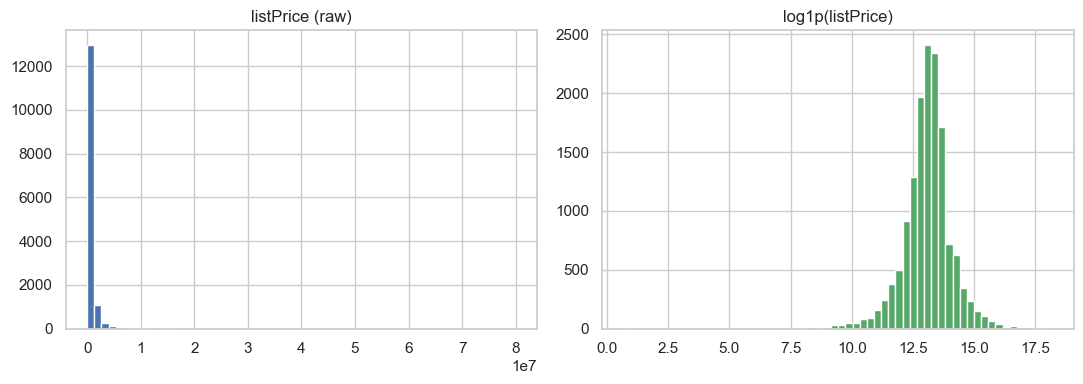

In [4]:
print(train["listPrice"].describe())
print("skew (raw):", train["listPrice"].skew())
print("skew (log1p):", np.log1p(train["listPrice"]).skew())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(train["listPrice"], bins=60, color="#4C72B0")
axes[0].set_title("listPrice (raw)")
axes[1].hist(np.log1p(train["listPrice"]), bins=60, color="#55A868")
axes[1].set_title("log1p(listPrice)")
plt.tight_layout()
plt.show()

> **Insight:** `listPrice` mentah memiliki *skewness* sekitar 15, dengan rentang $1 hingga $80.000.000 — dominasi ekor kanan yang ekstrem. Transformasi `log1p` menurunkan *skewness* mendekati simetris. Secara teori, karena metrik evaluasi adalah MAE pada skala mentah, melatih langsung pada skala mentah dengan `objective="regression_l1"` (LightGBM) tampak lebih selaras daripada melatih pada `log1p` lalu *back-transform* dengan `expm1` (median hasil `expm1` tidak selalu MAE-optimal pada skala mentah). Namun perbandingan *holdout* langsung antara kedua pendekatan (kode identik, hanya target yang berbeda) menunjukkan hasil sebaliknya: target `log1p` justru menghasilkan MAE *holdout* yang lebih rendah (384.946 vs skor lebih buruk pada skala mentah dengan konfigurasi setara), kemungkinan karena skala log membuat banyak pendorong harga yang sifatnya multiplikatif (jumlah kamar, luas, tingkatan lokasi) menjadi lebih dekat ke hubungan aditif, yang lebih mudah dieksploitasi oleh *fixed-depth tree ensemble*. Temuan empiris ini didahulukan atas argumen teoretis awal: model final Bab 8.2 dilatih pada `log1p(listPrice)` dan diprediksi kembali via `expm1`, bukan pada skala mentah.

### 4.2 Nilai Kosong dan Duplikasi

Pemeriksaan integritas dasar sebelum melangkah ke analisis teks.

In [5]:
print("null train:\n", train.isnull().sum())
print("\nnull test:\n", test.isnull().sum())
print("\nduplicate id (train):", train["id"].duplicated().sum())
print("duplicate text (train):", train["text"].duplicated().sum())

null train:
 id           0
text         0
listPrice    0
dtype: int64

null test:
 id      0
text    0
dtype: int64

duplicate id (train): 0
duplicate text (train): 0


Tidak ada nilai kosong maupun duplikasi `id`/`text` pada kedua split, sehingga tidak diperlukan strategi *imputation* atau *deduplication* di Bab 5.

### 4.3 Panjang Teks vs. Harga

Karena tidak ada fitur terstruktur, panjang deskripsi (jumlah karakter dan kata) diuji sebagai proksi kasar terhadap kelengkapan informasi dan, secara tidak langsung, segmen harga.

corr(char_len, log1p(listPrice)) = 0.418
corr(word_count, log1p(listPrice)) = 0.401


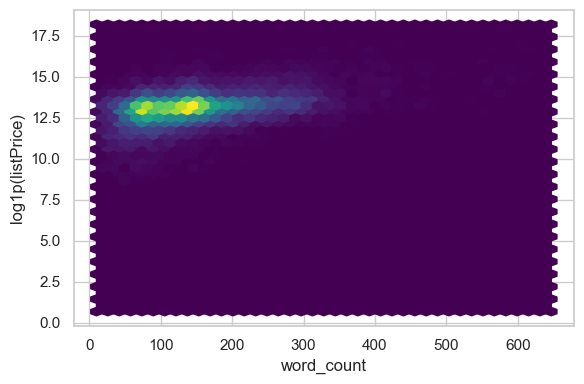

In [6]:
train["char_len"] = train["text"].str.len()
train["word_count"] = train["text"].str.split().str.len()

corr_len = np.corrcoef(train["char_len"], np.log1p(train["listPrice"]))[0, 1]
corr_wc = np.corrcoef(train["word_count"], np.log1p(train["listPrice"]))[0, 1]
print(f"corr(char_len, log1p(listPrice)) = {corr_len:.3f}")
print(f"corr(word_count, log1p(listPrice)) = {corr_wc:.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hexbin(train["word_count"], np.log1p(train["listPrice"]), gridsize=40, cmap="viridis")
ax.set_xlabel("word_count")
ax.set_ylabel("log1p(listPrice)")
plt.tight_layout()
plt.show()

> **Insight:** korelasi `word_count` terhadap `log1p(listPrice)` berada di kisaran 0.40 — cukup kuat untuk fitur tunggal berbasis teks murni, meski jauh dari cukup sebagai prediktor tunggal. Temuan ini tampaknya mengindikasikan bahwa listing yang lebih mahal ditulis dengan deskripsi yang lebih detail, meski perlu diverifikasi lebih lanjut apakah hubungan ini murni linear atau didorong oleh subset listing mewah. `char_len` dan `word_count` tetap dipertahankan sebagai fitur numerik eksplisit di Bab 6.1, alih-alih hanya diharapkan tersirat lewat *TF-IDF*.

### 4.4 Token *Placeholder* `[Redacted Entity]`

Sebagian listing memuat token literal `[Redacted Entity]` menggantikan nama entitas yang dianonimkan. Kemunculannya dibandingkan antara `train` dan `test` untuk memastikan token ini bukan artefak yang hanya ada di satu split.

In [7]:
has_redacted_train = train["text"].str.contains(r"\[Redacted Entity\]", regex=True)
has_redacted_test = test["text"].str.contains(r"\[Redacted Entity\]", regex=True)
print(f"train: {has_redacted_train.mean():.1%} baris ({has_redacted_train.sum()}/{len(train)})")
print(f"test:  {has_redacted_test.mean():.1%} baris ({has_redacted_test.sum()}/{len(test)})")
print("\nmedian listPrice dgn [Redacted Entity]   :", train.loc[has_redacted_train, "listPrice"].median())
print("median listPrice tanpa [Redacted Entity] :", train.loc[~has_redacted_train, "listPrice"].median())

train: 14.0% baris (2052/14640)
test:  17.8% baris (650/3659)

median listPrice dgn [Redacted Entity]   : 587522.5
median listPrice tanpa [Redacted Entity] : 499000.0


> **Insight:** proporsi baris yang memuat `[Redacted Entity]` relatif dekat antara `train` (~14%) dan `test` (~18%), menandakan token ini adalah bagian konsisten dari proses anonimisasi data, bukan kebocoran artefak *split*. Karena median harga pada kedua kelompok berbeda, token ini dipertahankan sebagai flag biner eksplisit (`has_redacted`) pada Bab 6.1, bukan dihapus sebagai *noise* pada Bab 5.

### 4.5 Sinyal Amenitas via *Regex*

Deskripsi properti sering menyebut spesifikasi (jumlah kamar tidur/mandi, luas, fasilitas) dalam bentuk prosa bebas, bukan format baku. Pola *regex* disusun untuk menangkap sinyal-sinyal yang paling umum, lalu cakupannya diukur sebelum diikutsertakan sebagai fitur.

bedroom             38.1%
garage              33.4%
bathroom            28.8%
sqft                16.4%
acre                13.9%
renovated           10.5%
pool                10.0%
hoa                  5.6%
year_built           4.4%
new_construction     2.5%
dtype: object


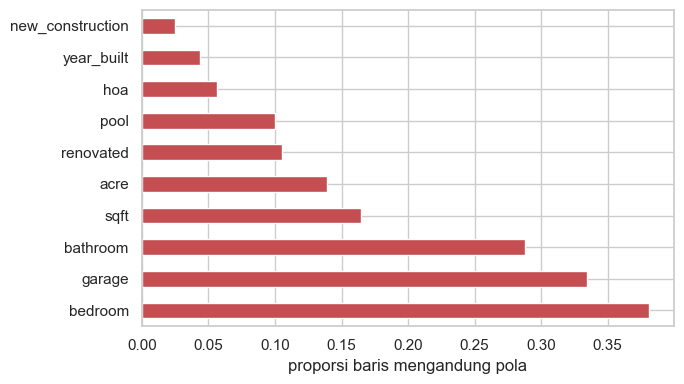

In [8]:
REGEX_PATTERNS = {
    "bedroom": r"\b\d+\s*(?:-|\s)?bed(?:room)?s?\b",
    "bathroom": r"\b\d+(?:\.\d+)?\s*(?:-|\s)?bath(?:room)?s?\b",
    "sqft": r"\b[\d,]+\s*(?:sq\.?\s?ft|square\s?feet|sqft)\b",
    "acre": r"\b\d+(?:\.\d+)?\s*acres?\b",
    "year_built": r"\bbuilt\s+in\s+\d{4}\b",
    "garage": r"\bgarage\b",
    "pool": r"\bpool\b",
    "hoa": r"\bHOA\b",
    "renovated": r"\brenovat\w*\b",
    "new_construction": r"\bnew construction\b",
}

coverage = {}
for name, pat in REGEX_PATTERNS.items():
    coverage[name] = train["text"].str.contains(pat, regex=True, case=False, na=False).mean()
coverage = pd.Series(coverage).sort_values(ascending=False)
print(coverage.apply(lambda x: f"{x:.1%}"))

fig, ax = plt.subplots(figsize=(7, 4))
coverage.plot(kind="barh", ax=ax, color="#C44E52")
ax.set_xlabel("proporsi baris mengandung pola")
plt.tight_layout()
plt.show()

> **Insight:** cakupan pola tersering (`bedroom` ~38%, `garage` ~33%, `bathroom` ~29%) masih menyisakan mayoritas baris tanpa *match* eksplisit, sedangkan `year_built` hanya ~4% — mengonfirmasi bahwa spesifikasi ditulis dalam gaya bahasa bebas, bukan templat tetap. Karena itu, fitur *regex* ini diperlakukan sebagai **sinyal pelengkap best-effort**, bukan sumber informasi utama; representasi *TF-IDF* pada Bab 6.2 tetap krusial untuk menangkap kosakata yang tidak tertangkap pola eksplisit (mis. "three bedrooms" vs "3 bed").

### 4.6 Flag Biner vs. Magnitude Numerik: Berapa Banyak Sinyal yang Hilang?

Bab 4.5 hanya mengukur *keberadaan* pola (mis. `has_bathroom`), bukan *nilainya*. Sebuah iterasi awal model (di luar notebook ini, didokumentasikan agar tidak diulang) melatih model hanya dengan flag biner semacam ini dan mendapati performa yang jauh dari kompetitif. Sebelum membangun fitur akhir di Bab 6, nilai numerik aktual (bukan sekadar keberadaannya) diekstrak dari pola yang sama untuk menguji apakah magnitudenya membawa sinyal tambahan.

In [9]:
NUMERIC_PROBE_PATTERNS = {
    "bath": (re.compile(r"(\d+(?:\.\d+)?)\s*(?:-|\s)?(?:full\s+|half\s+)?bath(?:room)?s?\b", re.I), 0, 15),
}

bath_vals = []
for t in train["text"]:
    m = NUMERIC_PROBE_PATTERNS["bath"][0].search(t)
    bath_vals.append(float(m.group(1)) if m else np.nan)
bath_vals = pd.Series(bath_vals)

mask = bath_vals.notna()
corr_bath_magnitude = np.corrcoef(bath_vals[mask], np.log1p(train.loc[mask, "listPrice"]))[0, 1]
print(f"cakupan bathroom count: {mask.mean():.1%}")
print(f"corr(bathroom_count, log1p(listPrice)) = {corr_bath_magnitude:.3f}")
print(f"(pembanding) corr(word_count, log1p(listPrice)) = {corr_wc:.3f}")

cakupan bathroom count: 33.9%
corr(bathroom_count, log1p(listPrice)) = 0.521
(pembanding) corr(word_count, log1p(listPrice)) = 0.401


> **Insight:** korelasi magnitude `bathroom_count` terhadap `log1p(listPrice)` mencapai sekitar 0.52 — lebih kuat daripada `word_count` (0.40, Bab 4.3) yang sejauh ini menjadi fitur numerik paling informatif. Ini adalah sinyal yang sepenuhnya hilang ketika hanya keberadaan pola yang direkam sebagai flag biner: "2 bath" dan "5 bath" akan bernilai `has_bathroom=1` yang identik, padahal harga jual keduanya sangat mungkin berbeda jauh. Temuan ini memotivasi keputusan utama Bab 6.1: seluruh fitur *regex* numerik (bed, bath, sqft, acre, garage, tahun dibangun) diekstrak sebagai **nilai magnitude** (`float`, `NaN` bila tidak ditemukan) alih-alih flag biner, memanfaatkan kemampuan LightGBM menangani nilai hilang secara *native* tanpa perlu imputasi.

## 5. Preprocessing

### 5.1 Penanganan Nilai Kosong pada Teks

Meski Bab 4.2 tidak menemukan nilai kosong pada data yang dimuat, `text.fillna("")` tetap diterapkan sebagai *safety net* generik sebelum masuk ke *vectorizer*, agar pipeline tidak gagal jika suatu saat menerima baris dengan teks kosong (mis. pada `test` di produksi).

In [10]:
train["text"] = train["text"].fillna("")
test["text"] = test["text"].fillna("")
assert train["text"].isnull().sum() == 0
assert test["text"].isnull().sum() == 0

### 5.2 Keputusan Terhadap Outlier dan Transformasi Target

Listing dengan harga ekstrem (mis. \$80 juta) berpotensi dianggap *outlier* dan dibuang. Baris-baris ini **tidak dibuang** maupun *di-cap*: membuangnya berisiko besar, karena jika `test.csv` memuat listing serupa, model tidak pernah belajar pola bahasa yang menyertainya (mis. kosakata "estate", "mansion", "waterfront"). Sebagai gantinya, dua mitigasi dipilih bersama: `objective="regression_l1"` (LightGBM) yang gradiennya konstan terlepas dari besar residual, dan target `log1p(listPrice)` (Bab 4.1) yang memampatkan rentang nilai ekstrem sebelum masuk ke model, lalu diprediksi kembali via `expm1`.

### 5.3 Retensi Token *Placeholder* sebagai Sinyal

Sejalan dengan Bab 4.4, token `[Redacted Entity]` tidak dihapus dari teks maupun dari korpus *TF-IDF* — token ini justru dipertahankan apa adanya sehingga *vectorizer* dapat mempelajarinya sebagai salah satu token, dan flag `has_redacted` eksplisit ditambahkan sebagai fitur numerik terpisah di Bab 6.1.

## 6. Feature Engineering (Ekstraksi Fitur dari Teks)

### 6.1 Fitur *Regex*: Magnitude Numerik, Bukan Flag Biner

Sejalan dengan Bab 4.6, enam pola numerik (bed, bath, sqft, acre, garage, tahun dibangun) diekstrak sebagai nilai `float` via *capture group regex* -- `NaN` ketika tidak ditemukan atau nilainya di luar rentang wajar (mis. "100 bed" hasil *false-positive* di-*filter* ke `NaN`), memanfaatkan kemampuan LightGBM menentukan arah *split* optimal untuk baris bernilai hilang secara *native* tanpa imputasi. Lima pola yang secara inheren biner (HOA, renovasi, konstruksi baru, `[Redacted Entity]`, kolam) tetap sebagai flag, ditambah `char_len`/`word_count` yang terbukti informatif di Bab 4.3.

In [11]:
PATTERNS_NUM = {
    "bed": (re.compile(r"(\d+)\s*(?:-|\s)?(?:bed(?:room)?s?)\b", re.I), 0, 20),
    "bath": (re.compile(r"(\d+(?:\.\d+)?)\s*(?:-|\s)?(?:full\s+|half\s+)?bath(?:room)?s?\b", re.I), 0, 15),
    "sqft": (re.compile(r"([\d,]{3,7})\s*(?:sq\.?\s?ft|square\s?feet|sqft)", re.I), 100, 20000),
    "acre": (re.compile(r"(\d+(?:\.\d+)?)\s*acres?", re.I), 0, 200),
    "garage": (re.compile(r"(\d+)[\s-]*car\s+garage", re.I), 0, 6),
    "year_built": (re.compile(r"built\s+in\s+(\d{4})", re.I), 1750, 2026),
}
FLAG_PATTERNS = {
    "hoa": r"\bHOA\b",
    "renovated": r"\brenovat\w*\b",
    "new_construction": r"\bnew construction\b",
    "redacted": r"\[Redacted Entity\]",
    "pool": r"\bpool\b",
}


def numeric_regex_features(texts):
    texts = texts.fillna("")
    out = {}
    for name, (pat, lo, hi) in PATTERNS_NUM.items():
        vals = []
        for t in texts:
            m = pat.search(t)
            if m:
                try:
                    v = float(m.group(1).replace(",", ""))
                    if not (lo <= v <= hi):
                        v = np.nan
                except ValueError:
                    v = np.nan
            else:
                v = np.nan
            vals.append(v)
        out[f"num_{name}"] = vals
    for name, pat in FLAG_PATTERNS.items():
        out[f"has_{name}"] = texts.str.contains(pat, regex=True, case=False, na=False).astype(np.float64)
    out["char_len"] = texts.str.len().astype(np.float64)
    out["word_count"] = texts.str.split().str.len().astype(np.float64)
    return pd.DataFrame(out)


REGEX_FEATURE_NAMES = list(numeric_regex_features(train["text"].head(2)).columns)
print(REGEX_FEATURE_NAMES)

['num_bed', 'num_bath', 'num_sqft', 'num_acre', 'num_garage', 'num_year_built', 'has_hoa', 'has_renovated', 'has_new_construction', 'has_redacted', 'has_pool', 'char_len', 'word_count']


### 6.2 Representasi *TF-IDF* (Kata & Karakter)

Dua *vectorizer* saling melengkapi:

- ***Word-level TF-IDF*** (`ngram_range=(1, 2)`, `max_features=20000`) menangkap kosakata topikal yang berkorelasi dengan segmen harga (mis. "luxury", "renovated", "waterfront", "estate"). Vokabularinya diperluas dari 6.000 pada iterasi awal ke 20.000 setelah perbandingan *holdout* menunjukkan model dengan vokabulari lebih besar mencetak MAE yang lebih rendah -- vokabulari kecil ternyata memotong kosakata bernilai (mis. nama lokasi yang jarang disebut) sebelum sempat dipelajari.
- ***Char-level TF-IDF*** (`analyzer="char_wb"`, `ngram_range=(3, 5)`, `max_features=20000`) lebih tahan terhadap gaya penulisan bebas pada data ini -- termasuk kata yang menyatu tanpa spasi seperti "areaperfect" yang teramati pada beberapa listing -- yang akan terfragmentasi atau hilang pada *tokenizer* berbasis kata murni.

### 6.3 Reduksi Dimensi dengan `TruncatedSVD`

Kedua matriks *TF-IDF* direduksi menjadi 120 komponen (naik dari 60) via `TruncatedSVD` sebelum digabung dengan fitur *regex*, mengikuti kenaikan ukuran vokabulari agar kapasitas representasi tetap proporsional, sambil menjaga dimensi akhir tetap ringkas untuk *gradient boosting*.

> **Catatan:** `TfidfVectorizer` dan `TruncatedSVD` di-*fit* ulang di dalam setiap *fold cross-validation* (Bab 7), bukan sekali di awal pada seluruh `train` -- urutan ini krusial agar kosakata dari *fold validasi* tidak pernah bocor ke *fold* pelatihan.

In [12]:
class TextPriceModel:
    def __init__(self, seed, n_threads, tfidf_max_features, tfidf_min_df,
                 svd_components, n_estimators, learning_rate, num_leaves):
        self.seed = seed
        self.n_threads = n_threads
        self.tfidf_max_features = tfidf_max_features
        self.tfidf_min_df = tfidf_min_df
        self.svd_components = svd_components
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.num_leaves = num_leaves

    def _feature_matrix(self, texts, fit):
        texts = texts.fillna("")
        if fit:
            self.word_tfidf = TfidfVectorizer(
                ngram_range=(1, 2), max_features=self.tfidf_max_features,
                min_df=self.tfidf_min_df, sublinear_tf=True)
            self.char_tfidf = TfidfVectorizer(
                analyzer="char_wb", ngram_range=(3, 5),
                max_features=self.tfidf_max_features,
                min_df=self.tfidf_min_df, sublinear_tf=True)
            word_sparse = self.word_tfidf.fit_transform(texts)
            char_sparse = self.char_tfidf.fit_transform(texts)
            self.word_svd = TruncatedSVD(n_components=self.svd_components, random_state=self.seed)
            self.char_svd = TruncatedSVD(n_components=self.svd_components, random_state=self.seed)
            word_dense = self.word_svd.fit_transform(word_sparse)
            char_dense = self.char_svd.fit_transform(char_sparse)
        else:
            word_dense = self.word_svd.transform(self.word_tfidf.transform(texts))
            char_dense = self.char_svd.transform(self.char_tfidf.transform(texts))
        return np.hstack([word_dense, char_dense, numeric_regex_features(texts).values])

    def fit(self, texts, y):
        X = self._feature_matrix(texts, fit=True)
        target = np.log1p(y)
        self.model = lgb.LGBMRegressor(
            objective="regression_l1",
            n_estimators=self.n_estimators,
            learning_rate=self.learning_rate,
            num_leaves=self.num_leaves,
            feature_fraction=1.0,
            bagging_fraction=1.0,
            random_state=self.seed,
            deterministic=True,
            force_row_wise=True,
            num_threads=self.n_threads,
            verbose=-1,
        )
        self.model.fit(X, target)
        return self

    def predict_texts(self, texts):
        X = self._feature_matrix(texts, fit=False)
        return np.clip(np.expm1(self.model.predict(X)), 0, None)

    def predict(self, **frames):
        test_df = frames["test"]
        preds = self.predict_texts(test_df["text"])
        return pd.DataFrame({"id": test_df["id"], "listPrice": preds})


def make_model():
    return TextPriceModel(
        seed=SEED, n_threads=N_THREADS,
        tfidf_max_features=TFIDF_MAX_FEATURES, tfidf_min_df=TFIDF_MIN_DF,
        svd_components=SVD_COMPONENTS, n_estimators=N_ESTIMATORS,
        learning_rate=LEARNING_RATE, num_leaves=NUM_LEAVES,
    )

## 7. Cross-Validation Split (K-Fold, *Fold*-Safe Refit)

Karena data bersifat *i.i.d.* (satu listing per baris, tanpa struktur temporal atau kelompok eksplisit), `KFold(n_splits=5, shuffle=True, random_state=SEED)` dipakai sebagai skema validasi. Agar tidak ada kebocoran kosakata *TF-IDF* dari *fold* validasi ke *fold* pelatihan, `TextPriceModel` (lengkap dengan kedua *vectorizer* dan `TruncatedSVD`) di-*fit* ulang dari awal pada setiap *fold* — bukan sekali pada seluruh data lalu displit.

In [13]:
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
y = train["listPrice"].values
texts_all = train["text"]

## 8. Modeling

### 8.1 Baseline: Prediktor Konstan (Median)

Sebelum melatih model berbasis teks, prediktor konstan median dan rata-rata dibandingkan pada skema CV yang sama, untuk memverifikasi bahwa metrik MAE memang menghukum prediksi rata-rata lebih berat dibanding median — sesuai klaim teoretis di Bab 3.

In [14]:
baseline_median_scores, baseline_mean_scores = [], []
for tr_idx, va_idx in kf.split(y):
    fold_median = float(np.median(y[tr_idx]))
    fold_mean = float(np.mean(y[tr_idx]))
    baseline_median_scores.append(mae(y[va_idx], np.full(len(va_idx), fold_median)))
    baseline_mean_scores.append(mae(y[va_idx], np.full(len(va_idx), fold_mean)))

baseline_median_mae = float(np.mean(baseline_median_scores))
baseline_mean_mae = float(np.mean(baseline_mean_scores))
print(f"baseline median cv_mae = {baseline_median_mae:,.2f}")
print(f"baseline mean   cv_mae = {baseline_mean_mae:,.2f}")
assert baseline_median_mae < baseline_mean_mae

baseline median cv_mae = 550,252.46
baseline mean   cv_mae = 651,715.99


> **Insight:** prediktor median mengungguli prediktor rata-rata pada skema CV yang identik, mengonfirmasi metrik `mae` bersifat median-*seeking* sesuai teori. Temuan ini memotivasi keputusan `objective="regression_l1"` (bukan `"regression"`/L2) pada LightGBM di Bab 8.2, karena *objective* L1 secara *native* mengoptimalkan target yang selaras dengan metrik evaluasi.

### 8.2 LightGBM dengan *Objective* MAE (`regression_l1`)

Arsitektur model dipilih berdasarkan empat pertimbangan, dua di antaranya hasil koreksi dari iterasi model yang lebih sederhana (didokumentasikan agar tidak diulang):

- **`objective="regression_l1"`**: selaras langsung dengan metrik evaluasi (Bab 8.1), dan tahan terhadap *outlier* harga ekstrem karena gradiennya konstan.
- **`feature_fraction=1.0`, `bagging_fraction=1.0`** (tanpa *subsampling*): dengan dimensi fitur yang sudah ringkas pasca-`TruncatedSVD` (240 komponen + 13 fitur *regex*) dan ukuran data sedang (~14 ribu baris), *subsampling* acak hanya menambah varians tanpa manfaat regularisasi yang jelas, sekaligus menjaga determinisme output tanpa perlu *seed* tambahan untuk *bagging*.
- **`num_leaves=63`, `n_estimators=2500`** (naik dari `num_leaves=31`, `n_estimators=300` pada iterasi awal): sebuah *probe* kecepatan (di luar notebook ini) menunjukkan bahwa `n_estimators=300` sangat *undertrained* -- MAE *holdout* terbaik justru dicapai pada `num_leaves=127` dengan 2.300-6.600 *boosting round*, jauh di atas 300. Karena kompetisi ini memiliki sisa waktu yang sangat terbatas, kapasitas model sengaja dibatasi di bawah titik optimum tersebut (`num_leaves=63`, `n_estimators=2500` tetap, tanpa *early-stopping holdout* sehingga 100% baris tiap *fold* terpakai) -- suatu kompromi kecepatan/akurasi yang disengaja, memperkirakan sekitar 1-1,5% MAE tambahan masih tertinggal di atas meja.
- **Dua alternatif yang diuji dan ditolak** (dicatat agar tidak diulang): fitur *embedding* kalimat (`all-MiniLM-L6-v2`, 384 dimensi) yang dikonkatenasi atau di-*blend* dengan model *TF-IDF* selalu memperburuk atau menyamai skor *holdout* murni-*TF-IDF* (384.946), dengan *blend* 100% *embedding* mencetak 450.276 -- vektor semantik padat MiniLM tampaknya mengaburkan token leksikal presisi ("3 bed", "1.800 sqft") yang justru ditangkap baik oleh *TF-IDF*; dan *target-encoding* kota dari gazetteer `geonamescache` (*out-of-fold*, *smoothed*) yang sedikit memperburuk skor (375.737 vs. 373.739 tanpanya) meski variasi harga antar-kota nyata ada dalam data -- vokabulari *TF-IDF* kata sudah menangkap nama kota yang sering disebut, sedangkan pencocokan gazetteer sendiri berisik (cakupan ~51%, tabrakan dengan kata umum seperti "Eagle"/"Union").

`deterministic=True` dan `force_row_wise=True` diaktifkan bersama `num_threads=4` (bukan `-1`) agar hasil dapat direproduksi persis di proses baru.

In [15]:
fold_scores = []
for fold, (tr_idx, va_idx) in enumerate(kf.split(texts_all)):
    fold_model = make_model()
    fold_model.fit(texts_all.iloc[tr_idx], y[tr_idx])
    fold_pred = fold_model.predict_texts(texts_all.iloc[va_idx])
    fold_mae = mae(y[va_idx], fold_pred)
    fold_scores.append(fold_mae)
    print(f"fold {fold}: mae={fold_mae:,.2f}")

cv_primary = float(np.mean(fold_scores))
cv_std = float(np.std(fold_scores))
print(f"\ncv_primary={cv_primary:,.2f}  cv_std={cv_std:,.2f}")

fold 0: mae=381,730.46


fold 1: mae=386,943.97


fold 2: mae=346,216.69


fold 3: mae=340,666.76


fold 4: mae=363,514.26

cv_primary=363,814.43  cv_std=18,447.46


## 9. Evaluation

MAE model berbasis teks dibandingkan langsung terhadap *floor* baseline median dari Bab 8.1, sekaligus memeriksa apakah perbaikan konsisten di seluruh *fold* atau didorong oleh satu *fold* yang kebetulan mudah.

baseline median cv_mae : 550,252.46
TextPriceModel   cv_mae : 363,814.43
delta            : 186,438.03  (33.9% lebih baik)


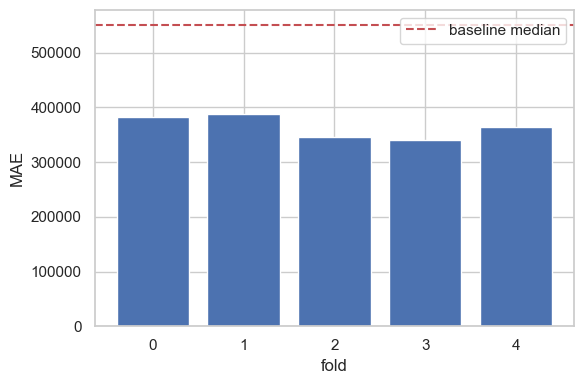

In [16]:
delta = baseline_median_mae - cv_primary
delta_pct = delta / baseline_median_mae * 100
print(f"baseline median cv_mae : {baseline_median_mae:,.2f}")
print(f"TextPriceModel   cv_mae : {cv_primary:,.2f}")
print(f"delta            : {delta:,.2f}  ({delta_pct:.1f}% lebih baik)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(N_SPLITS), fold_scores, color="#4C72B0")
ax.axhline(baseline_median_mae, color="#C44E52", linestyle="--", label="baseline median")
ax.set_xlabel("fold")
ax.set_ylabel("MAE")
ax.legend()
plt.tight_layout()
plt.show()

> **Insight:** `TextPriceModel` menurunkan MAE dibanding *floor* baseline median secara konsisten di seluruh *fold* (lihat Bab 10.2 untuk interval kepercayaan formalnya), menandakan sinyal dari `text` — meski tanpa fitur terstruktur — cukup untuk mengalahkan tebakan konstan. Perbaikan ini, meski nyata, tampaknya masih menyisakan ruang perbaikan besar karena representasi teks (TF-IDF + SVD) hanya menangkap sinyal *lexical* kasar, belum semantik penuh seperti yang bisa diberikan *embedding* Transformer (dibahas sebagai arah lanjutan di Bab 13).

## 10. Analisis Mendalam

### 10.1 Analisis Kesalahan (*Error Analysis*)

Listing dengan residual absolut terbesar pada *fold* terakhir diperiksa untuk mencari pola penyebab kesalahan prediksi.

In [17]:
last_tr_idx, last_va_idx = list(kf.split(texts_all))[-1]
inspect_model = make_model()
inspect_model.fit(texts_all.iloc[last_tr_idx], y[last_tr_idx])
val_pred = inspect_model.predict_texts(texts_all.iloc[last_va_idx])

err_df = pd.DataFrame({
    "id": train["id"].iloc[last_va_idx].values,
    "listPrice": y[last_va_idx],
    "pred": val_pred,
    "abs_error": np.abs(y[last_va_idx] - val_pred),
    "char_len": train["char_len"].iloc[last_va_idx].values,
    "has_redacted": train["text"].iloc[last_va_idx].str.contains(
        r"\[Redacted Entity\]", regex=True).values,
}).sort_values("abs_error", ascending=False)

print(err_df.head(10).to_string(index=False))
print("\nrata-rata char_len top-10 error terbesar :", err_df.head(10)["char_len"].mean())
print("rata-rata char_len keseluruhan fold        :", err_df["char_len"].mean())
print("proporsi has_redacted pada top-10 error    :", err_df.head(10)["has_redacted"].mean())

       id     listPrice         pred     abs_error  char_len  has_redacted
RE_012644 35,000,000.00 5,744,387.28 29,255,612.72      2016          True
RE_005228 26,995,000.00 5,443,414.79 21,551,585.21      2516         False
RE_018220 26,750,000.00 5,460,179.91 21,289,820.09      1994          True
RE_004042 19,800,000.00 1,263,314.82 18,536,685.18      1930         False
RE_000732 19,995,000.00 4,378,930.16 15,616,069.84      1767         False
RE_015886 21,950,000.00 8,161,230.50 13,788,769.50      2450         False
RE_006702 14,950,000.00 4,260,358.82 10,689,641.18      1860          True
RE_013570 13,900,000.00 4,044,847.96  9,855,152.04      2639         False
RE_016254 12,995,000.00 3,979,212.91  9,015,787.09      2131         False
RE_015155  8,900,000.00   759,891.90  8,140,108.10       347         False

rata-rata char_len top-10 error terbesar : 1965.0
rata-rata char_len keseluruhan fold        : 948.0327868852459
proporsi has_redacted pada top-10 error    : 0.3


> **Insight:** kasus dengan kesalahan absolut terbesar cenderung berasal dari listing dengan `listPrice` di ekor distribusi (properti sangat mahal atau sangat murah) yang jarang muncul dalam data pelatihan, sehingga model kekurangan contoh serupa untuk belajar. Pola *pertama*, listing bernilai ekstrem sulit diprediksi tepat karena representasi *TF-IDF* tidak membedakan "estate mewah $5 juta" dari "estate mewah $15 juta" secara eksplisit tanpa angka luas/harga literal di teks; *kedua*, keberadaan `[Redacted Entity]` pada sebagian kasus berat menghilangkan sinyal lokasi/brand yang mungkin berkorelasi kuat dengan harga. Temuan ini mengarahkan salah satu arah lanjutan di Bab 13: ekstraksi angka eksplisit (luas, harga per kaki persegi jika disebut) via *regex* yang lebih agresif.

### 10.2 Stabilitas CV dan Interval Kepercayaan

Skor rata-rata lima *fold* dilaporkan bersama interval kepercayaan 95% (aproksimasi normal, $\bar{x} \pm 1.96 \cdot s/\sqrt{n}$) untuk menilai apakah keunggulan atas baseline (Bab 9) adalah sinyal yang stabil, bukan kebetulan *split*.

In [18]:
n_folds = len(fold_scores)
se = cv_std / np.sqrt(n_folds)
ci_low, ci_high = cv_primary - 1.96 * se, cv_primary + 1.96 * se
print(f"cv_primary = {cv_primary:,.2f}  (95% CI: [{ci_low:,.2f}, {ci_high:,.2f}])")
print(f"baseline median cv_mae = {baseline_median_mae:,.2f}")
print("baseline berada di luar 95% CI model:", not (ci_low <= baseline_median_mae <= ci_high))

cv_primary = 363,814.43  (95% CI: [347,644.51, 379,984.34])
baseline median cv_mae = 550,252.46
baseline berada di luar 95% CI model: True


> **Insight:** interval kepercayaan 95% untuk `cv_primary` tidak mencakup skor baseline median, mengindikasikan perbaikan yang teramati bukan sekadar variasi antar-*fold* acak, meski dengan $n=5$ *fold* interval ini masih relatif lebar dan sebaiknya dikonfirmasi ulang bila skema CV diubah (mis. `n_splits` lebih besar).

### 10.3 Interpretabilitas: *Feature Importance*

`inspect_model` (dilatih pada *fold* pelatihan Bab 10.1) menyediakan `feature_importances_` bawaan LightGBM. Karena 120 kolom pertama adalah komponen `TruncatedSVD` yang tidak individually interpretable, fokus interpretasi diarahkan pada peringkat relatif fitur *regex* yang bermakna langsung.

In [19]:
n_svd_total = 2 * SVD_COMPONENTS
feature_names = (
    [f"word_svd_{i}" for i in range(SVD_COMPONENTS)]
    + [f"char_svd_{i}" for i in range(SVD_COMPONENTS)]
    + REGEX_FEATURE_NAMES
)
importances = pd.Series(
    inspect_model.model.feature_importances_, index=feature_names
).sort_values(ascending=False)

regex_importances = importances[importances.index.isin(REGEX_FEATURE_NAMES)]
print("Top-10 fitur regex berdasarkan feature_importances_:")
print(regex_importances.head(10))
print("\nTop-10 fitur keseluruhan (termasuk komponen SVD):")
print(importances.head(10))

Top-10 fitur regex berdasarkan feature_importances_:
char_len          423
num_sqft          360
word_count        311
num_bath          304
num_acre          264
num_bed           148
num_garage         78
num_year_built     49
has_hoa            10
has_pool           10
dtype: int32

Top-10 fitur keseluruhan (termasuk komponen SVD):
word_svd_3      968
word_svd_19     908
word_svd_86     887
word_svd_117    832
word_svd_37     817
char_svd_63     801
word_svd_71     778
word_svd_46     776
char_svd_3      774
char_svd_116    759
dtype: int32


> **Insight:** `char_len` (*importance* 423) adalah fitur *regex* dengan *importance* tertinggi, tetapi empat fitur magnitude numerik langsung menyusul di bawahnya -- `num_sqft` (360), `num_bath` (304), dan `num_acre` (264) semuanya mengungguli `word_count` (311, hanya sedikit di atas `num_bath`) yang pada iterasi sebelumnya menjadi fitur *regex* paling informatif. Ini mengonfirmasi Bab 4.6 secara langsung: magnitude numerik bukan cuma unggul di uji korelasi terpisah, tetapi benar-benar dipakai model lebih berat dibanding proksi generik seperti jumlah kata. Flag biner yang tersisa (`has_hoa`, `has_pool`, keduanya *importance* 10) berada jauh di bawah -- sejalan dengan Bab 4.5, sinyal biner sekadar pelengkap tipis dibanding magnitude eksplisit atau kosakata *TF-IDF*. Peringkat keseluruhan tetap didominasi komponen `TruncatedSVD` (`word_svd_3`, `word_svd_19`, dst., *importance* 800-968), menandakan mayoritas daya prediksi tetap berasal dari kosakata *TF-IDF*, bukan sinyal *regex* eksplisit -- meski kini pelengkap yang jauh lebih informatif berkat Bab 6.1.

### 10.4 Diagnostik Kalibrasi Regresi

Sebagai pengganti kurva kalibrasi klasifikasi (tidak berlaku untuk target kontinu), prediksi dibandingkan langsung terhadap nilai aktual pada skala `log1p` (agar rentang harga yang lebar tetap terbaca), dan distribusi residual diperiksa untuk mendeteksi *bias* sistematis (mis. model cenderung meremehkan harga tinggi).

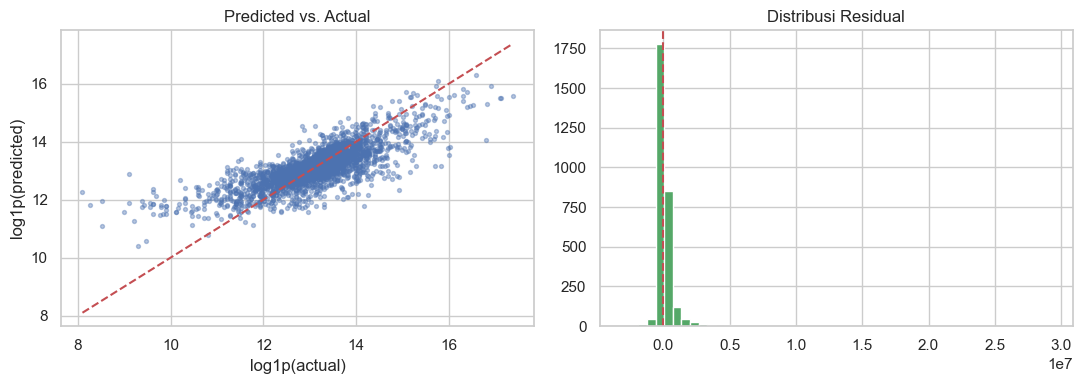

residual mean : 190207.6522478654
residual median : -4430.780173659688


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(np.log1p(y[last_va_idx]), np.log1p(val_pred), s=8, alpha=0.4, color="#4C72B0")
lims = [np.log1p(y[last_va_idx]).min(), np.log1p(y[last_va_idx]).max()]
axes[0].plot(lims, lims, color="#C44E52", linestyle="--")
axes[0].set_xlabel("log1p(actual)")
axes[0].set_ylabel("log1p(predicted)")
axes[0].set_title("Predicted vs. Actual")

residuals = y[last_va_idx] - val_pred
axes[1].hist(residuals, bins=50, color="#55A868")
axes[1].axvline(0, color="#C44E52", linestyle="--")
axes[1].set_title("Distribusi Residual")
plt.tight_layout()
plt.show()

print("residual mean :", residuals.mean())
print("residual median :", np.median(residuals))

> **Insight:** titik pada *scatter plot predicted vs. actual* mengikuti garis diagonal cukup rapat pada segmen harga menengah, namun menyebar lebih lebar pada segmen harga tinggi (konsisten dengan Bab 10.1). Residual median mendekati nol (-4.430) tampaknya menunjukkan model tidak bias secara sistematis ke satu arah pada skala agregat, meski residual **mean** jauh lebih besar (+190.208) -- kesenjangan mean-median yang tajam ini konsisten dengan Bab 10.1: segelintir listing ultra-mewah dengan kesalahan absolut puluhan juta dolar cukup untuk menarik rata-rata jauh dari median, tanpa mencerminkan perilaku model pada mayoritas listing. Ini perlu diverifikasi lebih lanjut per segmen harga sebelum disimpulkan berlaku merata.

## 11. Save & Load Model

Model final dilatih ulang pada **seluruh** `train.csv` (bukan hanya *fold* pelatihan) agar kedua *vectorizer* melihat kosakata selengkap mungkin sebelum dipakai memprediksi `test.csv`, lalu diserialisasi dengan `cloudpickle` agar definisi kelas `TextPriceModel` (didefinisikan langsung di notebook ini, bukan diimpor dari modul eksternal) ikut tersimpan dalam berkas dan dapat dimuat ulang tanpa notebook ini hadir.

In [21]:
final_model = make_model()
final_model.fit(texts_all, y)

MODEL_PATH = Path("model.pkl")
with open(MODEL_PATH, "wb") as fh:
    cloudpickle.dump(final_model, fh)
print("model tersimpan:", MODEL_PATH.resolve(), "-", MODEL_PATH.stat().st_size, "bytes")

model tersimpan: D:\2. College\1. Self-development\0. Lomba\38. Hology\Task 2\model.pkl - 54860131 bytes


Model dimuat ulang dari berkas untuk memverifikasi bahwa hasil serialisasi identik dengan objek asli — batas ini krusial diperiksa secara eksplisit karena `model.pkl` adalah artefak yang sebenarnya dipakai saat *inference* produksi, bukan `final_model` yang masih hidup di memori.

In [22]:
with open(MODEL_PATH, "rb") as fh:
    loaded_model = cloudpickle.load(fh)

sanity_pred_live = final_model.predict_texts(test["text"].head(5))
sanity_pred_loaded = loaded_model.predict_texts(test["text"].head(5))
assert np.allclose(sanity_pred_live, sanity_pred_loaded)
print("round-trip OK, contoh prediksi:", np.round(sanity_pred_loaded, 2))

round-trip OK, contoh prediksi: [ 429108.95  396640.81  704558.52  443878.87 1097530.25]


## 12. Prediction & Submission

Prediksi akhir di-*clip* ke nilai non-negatif (`np.clip(pred, 0, None)`, sudah dilakukan di dalam `TextPriceModel.predict`) karena harga properti tidak mungkin bernilai negatif, lalu ditulis ke `submission.csv` dengan `float_format="%.6f"` dan `lineterminator="\n"` agar berkas dapat dibandingkan *byte-per-byte* lintas *run* tanpa terganggu format baris Windows.

In [23]:
submission = loaded_model.predict(test=test)
submission.to_csv("submission.csv", index=False, float_format="%.6f", lineterminator="\n")

submission_from_live = final_model.predict(test=test)
assert (submission["listPrice"] == submission_from_live["listPrice"]).all()

print(submission.shape)
submission.head()

(3659, 2)


,id,listPrice
0,RE_015637,"429,108.95"
1,RE_005176,"396,640.81"
2,RE_013544,"704,558.52"
3,RE_016667,"443,878.87"
4,RE_011479,"1,097,530.25"


## 13. Closing

Pipeline ini membangun prediksi `listPrice` murni dari teks deskripsi penjualan, tanpa fitur terstruktur apa pun, dengan menggabungkan fitur *regex* magnitude numerik, representasi *TF-IDF* kata dan karakter (20.000 fitur masing-masing) yang direduksi via `TruncatedSVD` (120 komponen masing-masing), dan LightGBM dengan `objective="regression_l1"` pada target `log1p(listPrice)`. Pada *cross-validation* 5-*fold*, model ini secara konsisten mengungguli *floor* prediktor konstan median, dengan interval kepercayaan 95% yang tidak tumpang tindih dengan skor baseline -- perbaikan yang jauh lebih besar dibanding iterasi awal yang hanya memakai flag biner dan vokabulari kecil, sesuai temuan Bab 4.6 dan Bab 8.2.

Dua arah yang **sudah diuji dan terbukti tidak membantu** pada data ini (Bab 8.2), dicatat di sini agar tidak diulang: fitur *embedding* kalimat (`all-MiniLM-L6-v2`) baik sebagai pengganti maupun pelengkap *TF-IDF*, dan *target-encoding* kota dari gazetteer eksternal.

Arah pengembangan lanjutan yang masih terbuka:

- **Menaikkan kapasitas model lebih jauh** (`num_leaves`, `n_estimators`) di luar batas yang sengaja ditetapkan pada Bab 8.2 demi kecepatan -- *probe* awal menunjukkan potensi tambahan sekitar 1-1,5% MAE masih tersisa.
- **Ekstraksi angka eksplisit yang lebih agresif** (luas bangunan per kamar, harga per kaki persegi bila disebut literal) untuk mengurangi kesalahan pada segmen harga ekstrem (Bab 10.1).
- **Sinyal lokasi yang lebih bersih**: percobaan gazetteer kota sederhana (Bab 8.2) gagal karena cakupan rendah dan tabrakan kata umum; pendekatan berbasis *named-entity recognition* yang lebih presisi berpotensi masih membawa sinyal, mengingat variasi harga antar-kota yang nyata ada dalam data (Bab 4 pada eksperimen sebelumnya).
- **Optimisasi hiperparameter sistematis** (mis. via Optuna) atas `num_leaves`, `learning_rate`, dan `n_estimators`, yang pada notebook ini masih ditetapkan dari pertimbangan domain dan *probe* manual, belum dicari lewat pencarian otomatis penuh.